In [3]:
import os
import cv2
import pandas as pd
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
import matplotlib.pyplot as plt
from skimage import measure
from scipy import ndimage
from skimage.morphology import skeletonize
from skimage.measure import regionprops, label
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from patchify import patchify, unpatchify
from task_8_helpers import f1, load_images_from_folder, crop_to_petri_dish, padder, divide_mask_into_sections, load_mask, extract_rsa 

In [4]:
# Load the model trained in task5_training.ipynb
patch_size = 128
file_name = f'C:/Users/salop/Documents/GitHub/FAI2/2024-25b-fai2-adsai-MariaSalop230574/datalab_tasks/task5/SalopMaria_230574_unet_model_{patch_size}px_V2.h5'
model = load_model(file_name, custom_objects={"f1": f1})

In [5]:
# Define the path to the dataset
dataset_path = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\images"

# Load the dataset
images = load_images_from_folder(dataset_path)
print(f"Loaded {len(images)} images from {dataset_path}")

Loaded 18 images from C:\Users\salop\Documents\Data\Kaggle\Kaggle\images


In [16]:
# Get a list of all image file paths in the folder
image_files = [os.path.join(dataset_path, file) for file in os.listdir(dataset_path) if file.endswith(('.png'))]
masks_folder = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks"
# Define patch size and step size
patch_size = 128
step_size = 128

# Iterate over all image files
for image_path in image_files:
    # Extract the original image name without the extension
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    
    # Load and process the image
    image = cv2.imread(image_path)
    petri_dish, bounding_box = crop_to_petri_dish(image)  # Adjust based on your cropping function
    petri_dish_padded = padder(petri_dish, patch_size)
    petri_dish_grayscale = cv2.cvtColor(petri_dish_padded, cv2.COLOR_BGR2GRAY)

    # PATCH: Split the grayscale image into patches
    image_patches = patchify(petri_dish_grayscale, (patch_size, patch_size), step=step_size)

    # Initialize an empty array for predictions
    predicted_patches = np.zeros(image_patches.shape, dtype=np.uint8)

    # PREDICT: Process each patch and generate predictions
    for i in range(image_patches.shape[0]):  # Number of patches in height
        for j in range(image_patches.shape[1]):  # Number of patches in width
            patch = image_patches[i, j, ...]
            patch_normalized = patch / 255.0  # Normalize patch to [0, 1]
            patch_normalized = np.expand_dims(patch_normalized, axis=(0, -1))  # Add batch and channel dimensions
            predicted_patch = model.predict(patch_normalized)
            predicted_patches[i, j, ...] = (predicted_patch[0, ..., 0] > 0.25).astype(np.uint8)

    # UNPATCH: Combine all predicted patches back into a full-size mask
    predicted_mask = unpatchify(predicted_patches, petri_dish_grayscale.shape)

    # Save the mask with the format "image_name_mask.png"
    mask_filename = os.path.join(masks_folder, f"{image_name}_mask.png")
    cv2.imwrite(mask_filename, predicted_mask * 255)  # Multiply by 255 for visibility

    # Print progress
    print(f"Processed and saved mask for {image_name} as {mask_filename}")

1/1 [==============================] - 0s 19ms/step
Processed and saved mask for test_image_1 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_1_mask.png
1/1 [==============================] - 0s 16ms/step
Processed and saved mask for test_image_10 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_10_mask.png
1/1 [==============================] - 0s 19ms/step
Processed and saved mask for test_image_11 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_11_mask.png
1/1 [==============================] - 0s 18ms/step
Processed and saved mask for test_image_12 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_12_mask.png
1/1 [==============================] - 0s 21ms/step
Processed and saved mask for test_image_13 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_13_mask.png
1/1 [==============================] - 0s 17ms/step
Processed and saved mask for test_image_14 as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks

In [17]:
masks = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks"

# Iterate over all mask files
mask_files = [os.path.join(masks, file) for file in os.listdir(masks) if file.endswith('_mask.png')]

# Divide each mask by 250
for mask_file in mask_files:
    mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    divided_mask = mask / 250.0
    divided_mask_filename = mask_file.replace('_mask.png', '_mask.png')
    cv2.imwrite(divided_mask_filename, (divided_mask).astype(np.uint8))  # Save the divided mask
    print(f"Processed and saved divided mask for {os.path.basename(mask_file)} as {divided_mask_filename}")

Processed and saved divided mask for test_image_10_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_10_mask.png
Processed and saved divided mask for test_image_11_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_11_mask.png
Processed and saved divided mask for test_image_12_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_12_mask.png
Processed and saved divided mask for test_image_13_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_13_mask.png
Processed and saved divided mask for test_image_14_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_14_mask.png
Processed and saved divided mask for test_image_15_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_15_mask.png
Processed and saved divided mask for test_image_16_mask.png as C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_16_mask.png
Processed and saved divided mask for test_image_

In [18]:
import os
import cv2
import numpy as np

# Function to divide the mask into sections
def divide_mask_into_sections(predicted_mask, sections=5):
    height, width = predicted_mask.shape
    section_width = width // sections
    divided_sections = []

    for i in range(sections):
        start_x = i * section_width
        end_x = (i + 1) * section_width if i < sections - 1 else width
        divided_sections.append(predicted_mask[:, start_x:end_x])

    return divided_sections

# Paths
masks_folder = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks"
output_folder = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks"
os.makedirs(output_folder, exist_ok=True)

# List all mask files
mask_files = [os.path.join(masks_folder, file) for file in os.listdir(masks_folder) if file.endswith(('.png', '.jpg', '.jpeg'))]

# Process each mask file
for mask_file in mask_files:
    print(f"Processing mask file: {mask_file}")
    mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    
    # Skip if the mask could not be loaded
    if mask is None:
        print(f"Failed to load mask: {mask_file}")
        continue

    # Divide mask into sections
    mask_sections = divide_mask_into_sections(mask, sections=5)

    # Save each section as an image
    for i, section in enumerate(mask_sections):
        section_filename = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(mask_file))[0].replace('_mask', f'_plant_{i + 1}')}.png")
        cv2.imwrite(section_filename, section)
        print(f"Saved section: {section_filename}")


Processing mask file: C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_10_mask.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Processing mask file: C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_11_mask.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Saved section: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Saved section: C:\

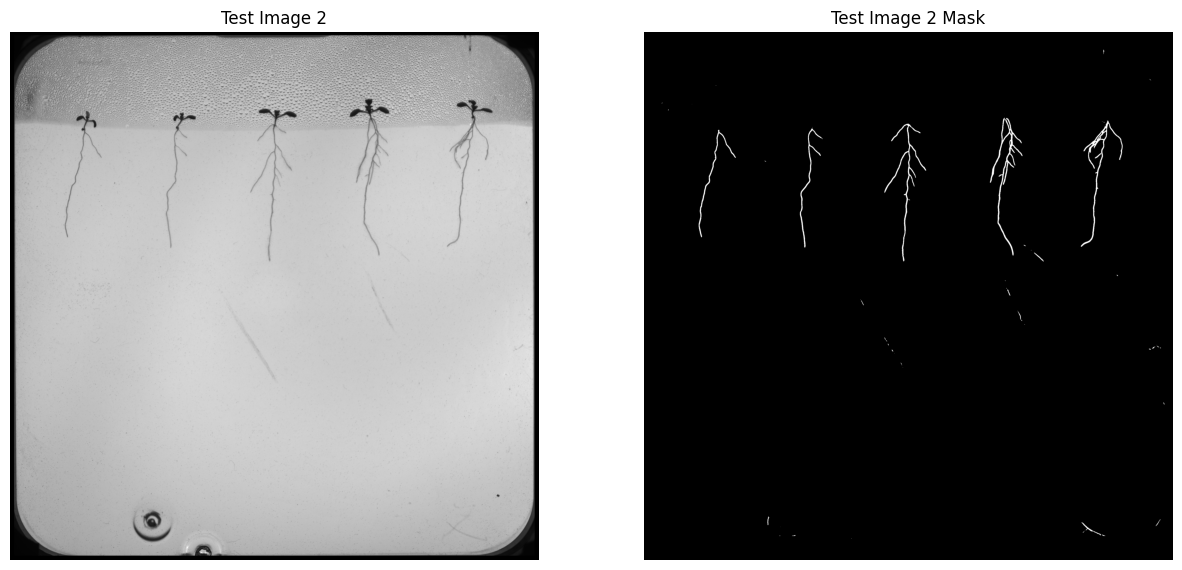

In [93]:
# Load and process the image
image_path = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\images\test_image_17.png"
image = cv2.imread(image_path)
petri_dish, bounding_box = crop_to_petri_dish(image)  # Adjust based on your cropping function
petri_dish_padded = padder(petri_dish, patch_size)
image = petri_dish_padded

# Convert the image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load the mask
mask_path = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_17_mask.png"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Plot the image and mask side by side
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.title("Test Image 2")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Test Image 2 Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

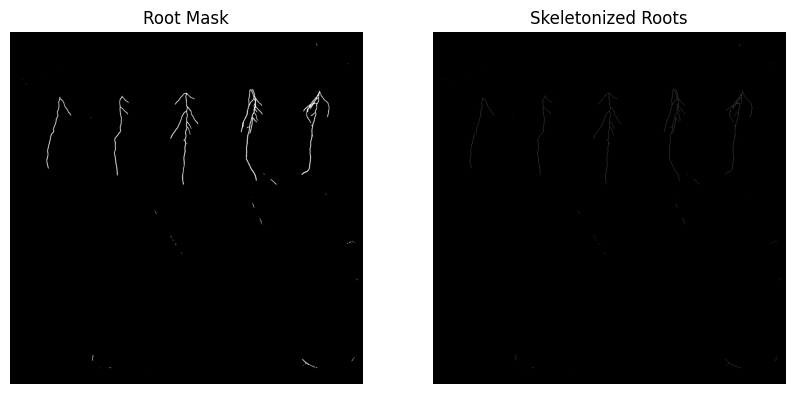

         length       width                                  centroid  \
0     17.656854   20.756119               (107.5, 2446.3333333333335)   
1      1.207107    3.677089               (120.0, 2445.6666666666665)   
2      1.000000    3.265986                           (256.0, 2690.0)   
3      1.207107    3.677089               (259.0, 2694.6666666666665)   
4      0.000000    0.000000                           (264.0, 2700.0)   
5      0.000000    2.000000                            (289.5, 383.0)   
6      1.000000    3.265986                             (382.0, 97.0)   
7      1.000000    3.265986                             (384.0, 93.0)   
8      0.000000    0.000000                            (389.0, 255.0)   
9      2.207107    4.680206                           (419.5, 128.75)   
10     0.000000    0.000000                           (441.0, 1920.0)   
11  1858.775829  734.736831   (721.0794902912621, 1924.0455097087379)   
12     0.000000    0.000000                        

In [92]:
filepath = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\masks\test_image_17_mask.png"
mask = load_mask(filepath)
root_data, skeleton = extract_rsa(mask)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Root Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Skeletonized Roots")
plt.imshow(skeleton, cmap="gray")
plt.axis("off")
plt.show()

root_df = pd.DataFrame(root_data)
print(root_df)

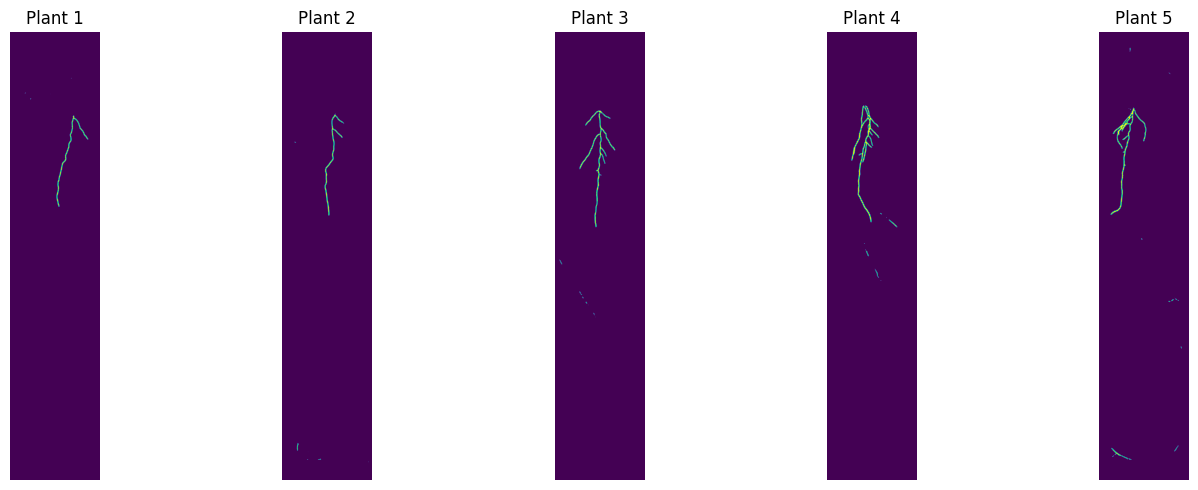

In [91]:
# Define the paths to the divided mask sections
mask_section_paths = [
    r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png",
    r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png",
    r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png",
    r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png",
    r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png"
]

# Load the mask sections
mask_sections = [cv2.imread(path, cv2.IMREAD_GRAYSCALE) for path in mask_section_paths]

# Plot the mask sections
fig, axs = plt.subplots(1, 5, figsize=(15, 5))
for i, section in enumerate(mask_sections):
    axs[i].imshow(section)
    axs[i].axis('off')
    axs[i].set_title(f'Plant {i + 1}')
plt.tight_layout()
plt.show()

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png
Highest node: (628, 402), Lowest node: (1668, 281)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_1.png


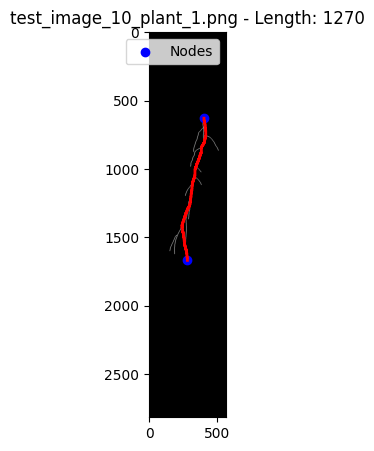

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png
Highest node: (639, 309), Lowest node: (2149, 43)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_2.png


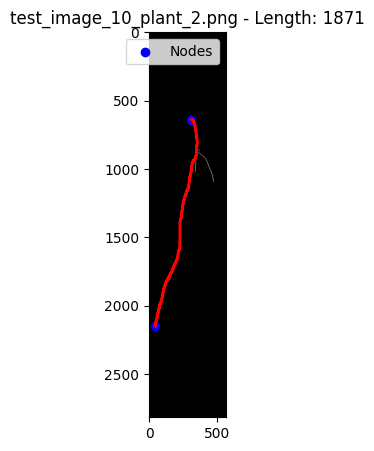

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png
Highest node: (784, 289), Lowest node: (1982, 215)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_3.png


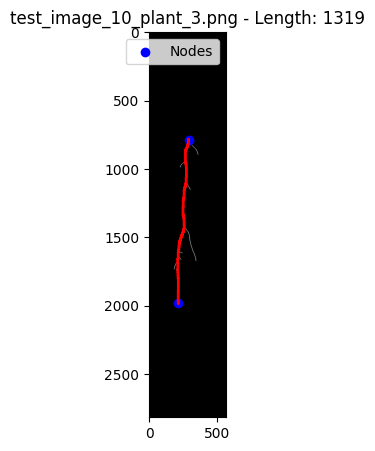

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png
Highest node: (558, 243), Lowest node: (1791, 328)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_4.png


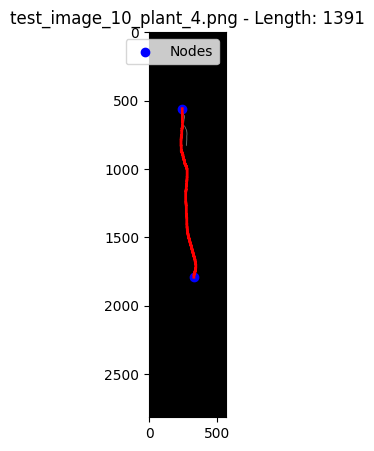

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png
Highest node: (592, 208), Lowest node: (1642, 285)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_10_plant_5.png


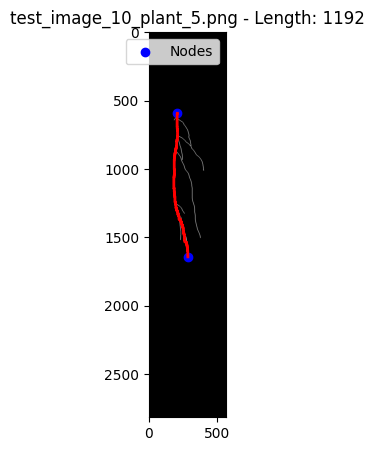

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png
Highest node: (639, 382), Lowest node: (1646, 168)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_1.png


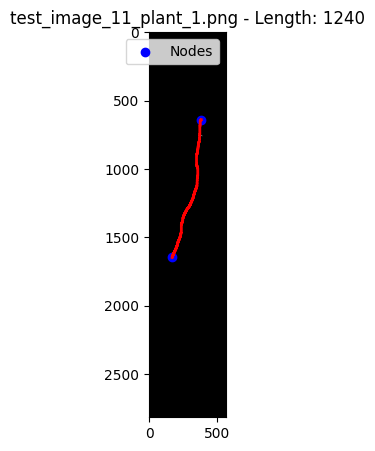

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png
Highest node: (743, 268), Lowest node: (2063, 90)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_2.png


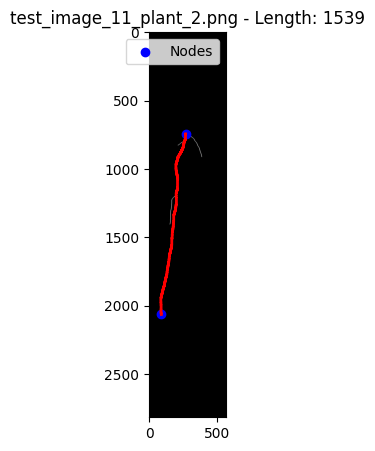

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png
Highest node: (558, 282), Lowest node: (1927, 186)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_3.png


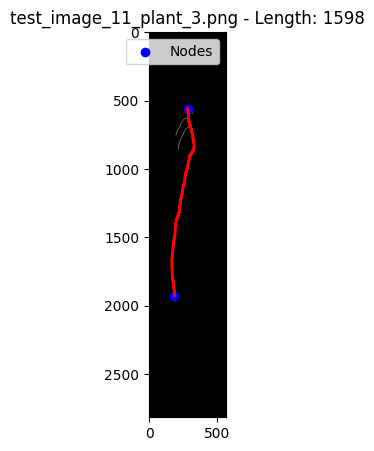

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png
Highest node: (646, 231), Lowest node: (2109, 226)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_4.png


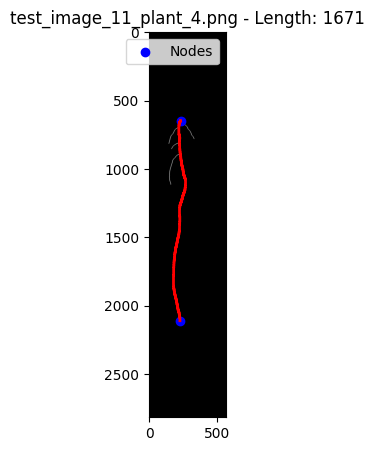

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png
Highest node: (670, 179), Lowest node: (1765, 0)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_11_plant_5.png


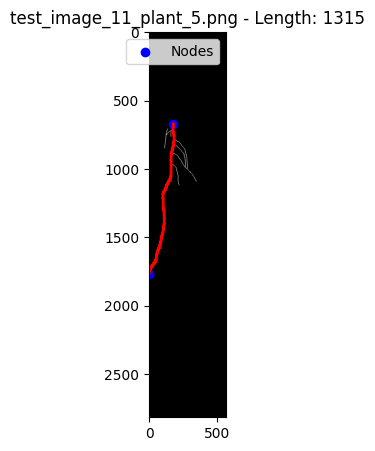

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png
Highest node: (483, 379), Lowest node: (1417, 456)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_1.png


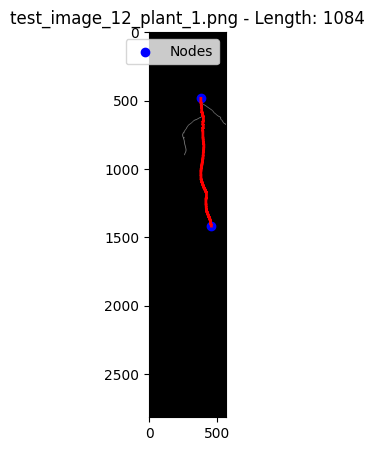

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png
Highest node: (476, 343), Lowest node: (1483, 286)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_2.png


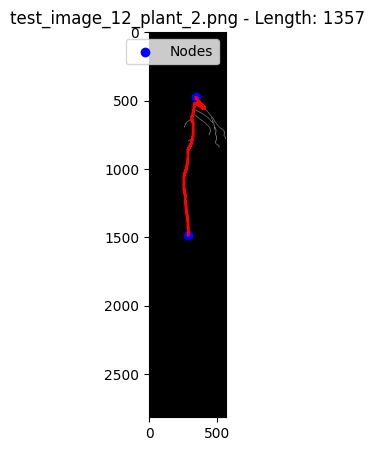

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png
Highest node: (447, 295), Lowest node: (1322, 263)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_3.png


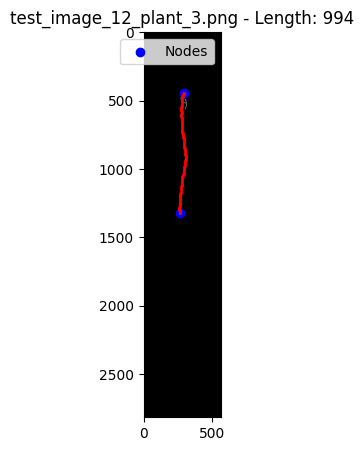

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png
Highest node: (435, 230), Lowest node: (1357, 64)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_4.png


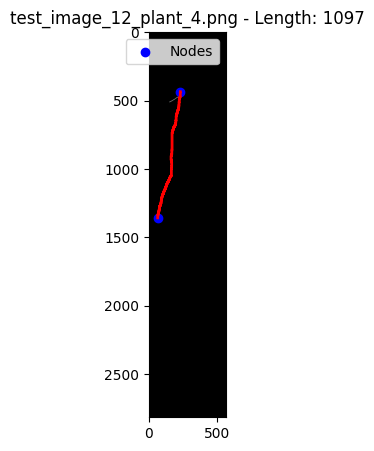

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png
Highest node: (442, 193), Lowest node: (1378, 85)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_12_plant_5.png


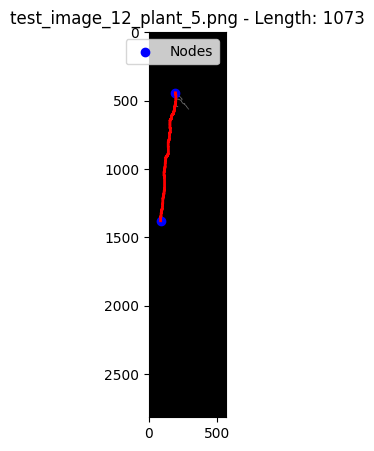

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png
Highest node: (511, 384), Lowest node: (1854, 357)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_1.png


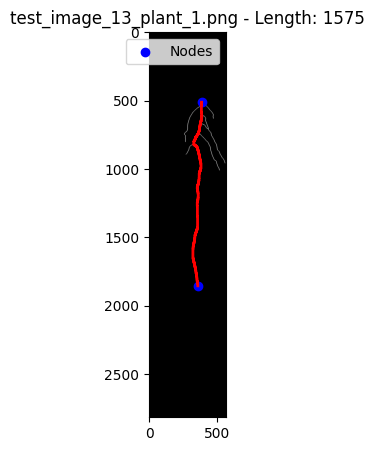

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png
Highest node: (508, 333), Lowest node: (1637, 363)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_2.png


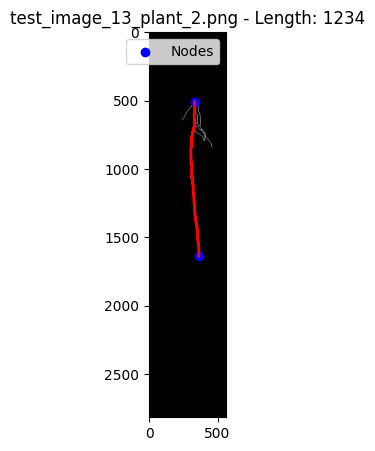

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png
Highest node: (511, 317), Lowest node: (1551, 193)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_3.png


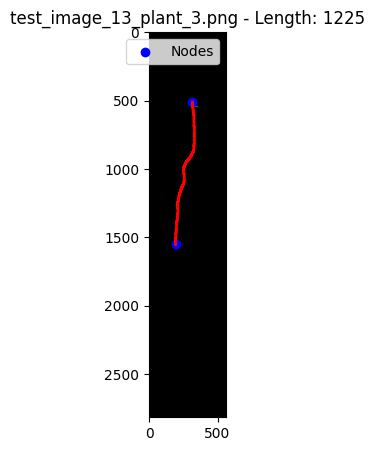

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png
Highest node: (503, 258), Lowest node: (1771, 269)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_4.png


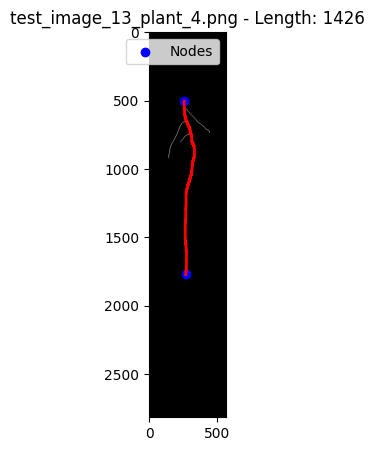

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png
Highest node: (495, 216), Lowest node: (1928, 67)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_13_plant_5.png


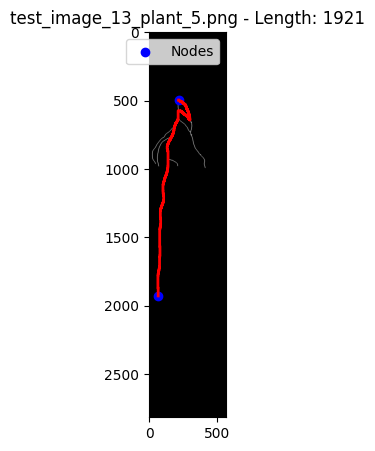

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_1.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_1.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_2.png
Highest node: (466, 328), Low

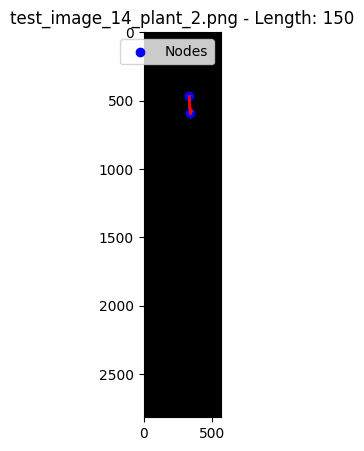

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_4.png
Highest node: (461, 227), Low

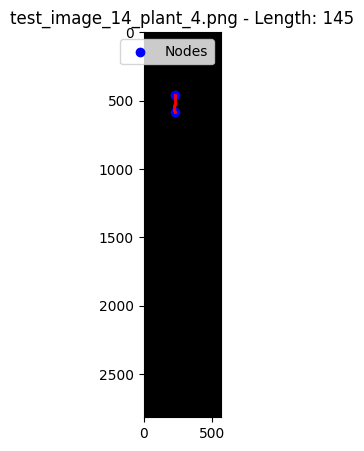

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png
Highest node: (174, 58), Lowest node: (248, 207)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_14_plant_5.png


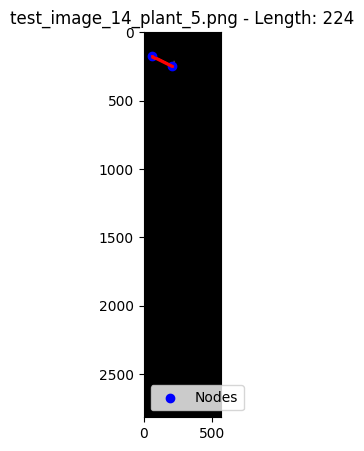

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png
Highest node: (547, 401), Lowest node: (825, 442)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_1.png


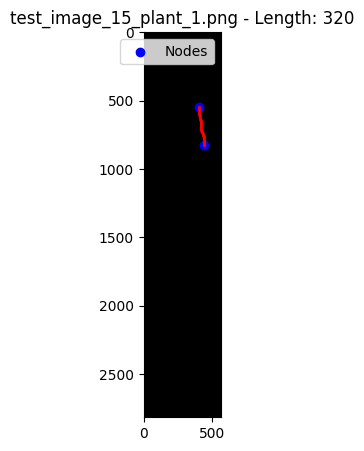

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png
Highest node: (527, 363), Lowest node: (804, 373)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_2.png


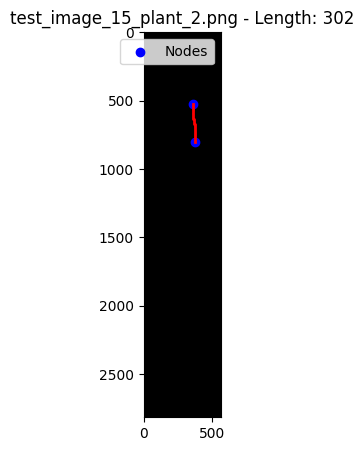

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png
Highest node: (520, 317), Lowest node: (827, 277)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_3.png


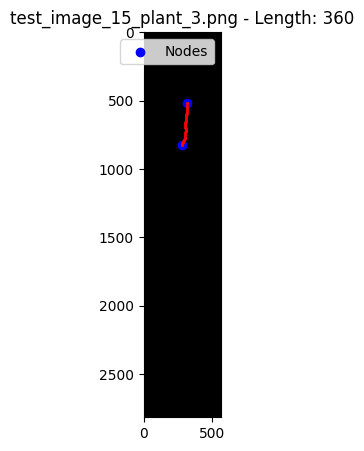

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png
Highest node: (511, 257), Lowest node: (837, 239)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_4.png


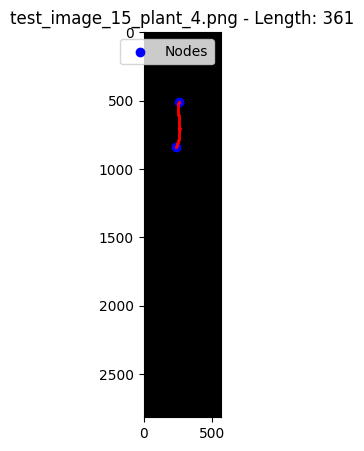

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png
Highest node: (511, 211), Lowest node: (763, 203)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_15_plant_5.png


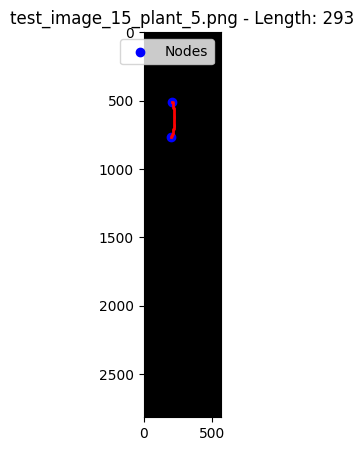

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png
Highest node: (476, 383), Lowest node: (860, 422)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_1.png


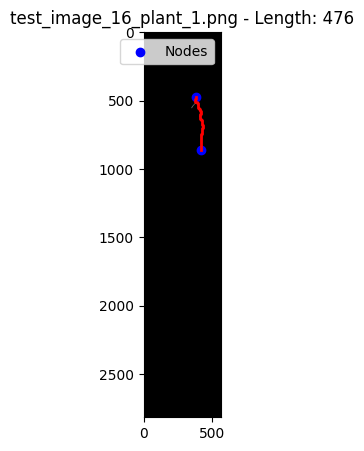

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png
Highest node: (485, 356), Lowest node: (853, 393)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_2.png


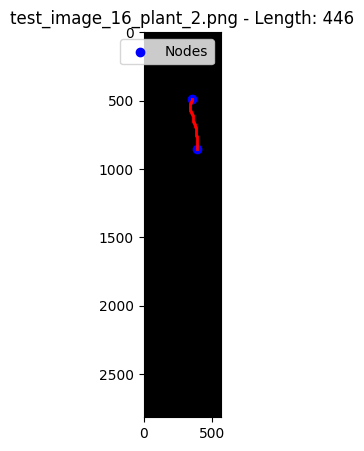

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_4.png
Highest node: (511, 247), Low

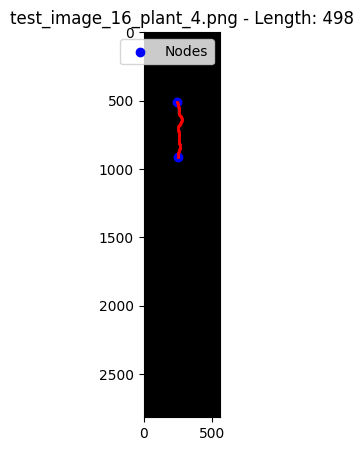

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png
Highest node: (528, 216), Lowest node: (864, 222)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_16_plant_5.png


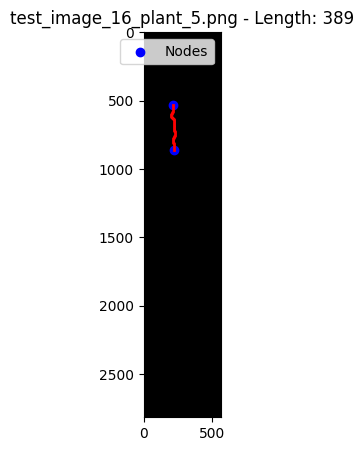

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png
Highest node: (528, 398), Lowest node: (1096, 306)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_1.png


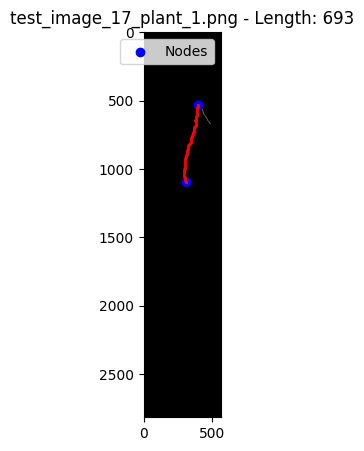

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png
Highest node: (515, 332), Lowest node: (1150, 291)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_2.png


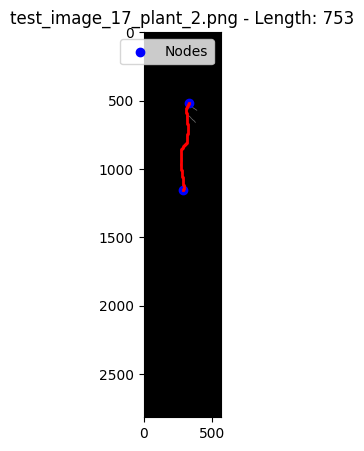

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png
Highest node: (491, 281), Lowest node: (1225, 255)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_3.png


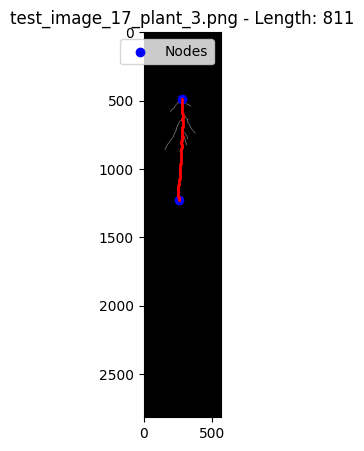

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png
Highest node: (460, 230), Lowest node: (1193, 275)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_4.png


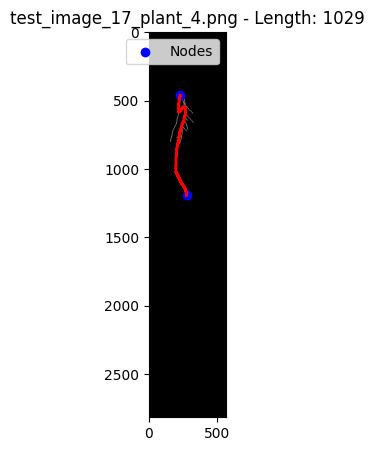

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png
Highest node: (476, 217), Lowest node: (1146, 75)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_17_plant_5.png


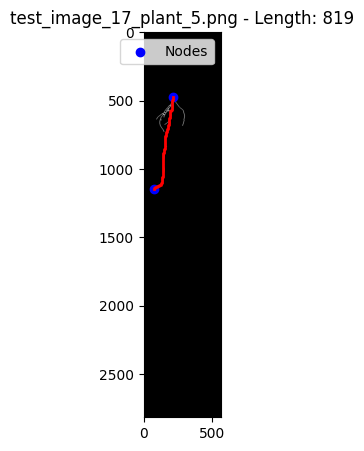

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png
Highest node: (547, 400), Lowest node: (1073, 311)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_1.png


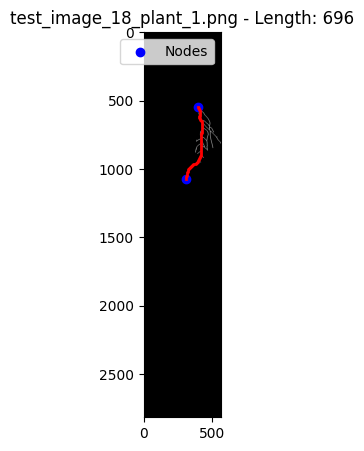

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png
Highest node: (495, 347), Lowest node: (1538, 388)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_2.png


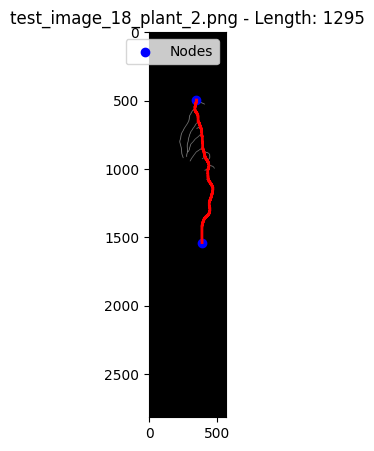

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_4.png
Highest node: (558, 250), Low

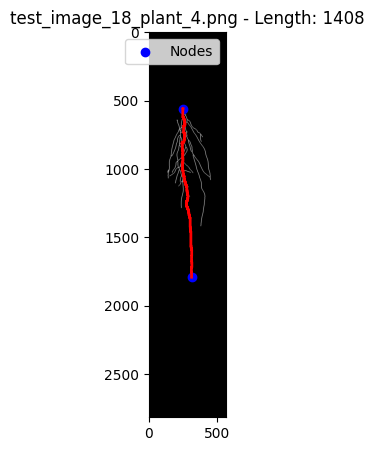

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png
Highest node: (504, 179), Lowest node: (1790, 262)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_18_plant_5.png


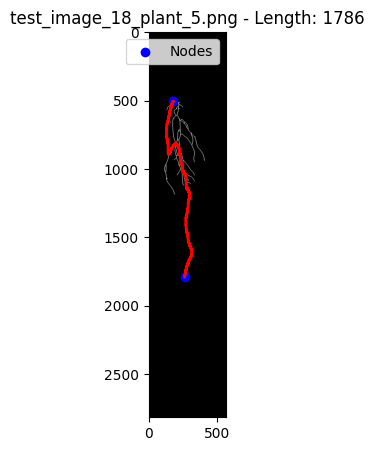

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png
Highest node: (485, 449), Lowest node: (1008, 471)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_1.png


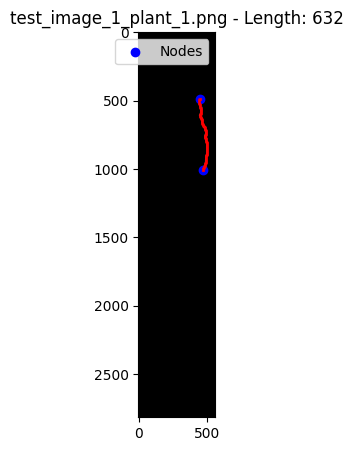

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_2.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_2.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_3.png
Highest node: (492, 279), Lowest node:

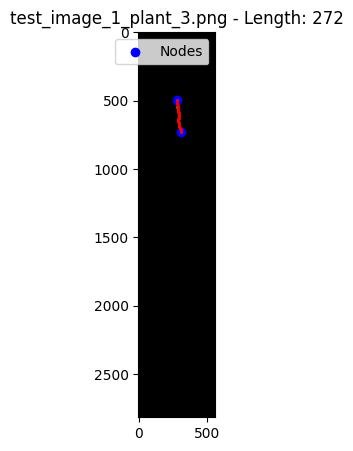

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_4.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_4.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_5.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_1_plant_5.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_1.png
Primary root isolated for C

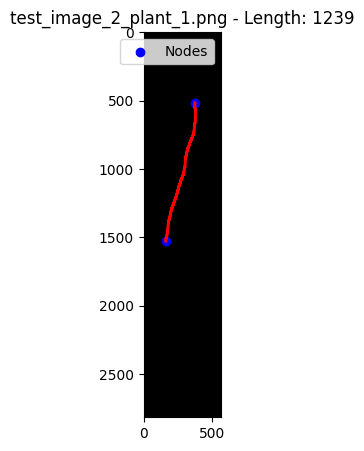

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png
Highest node: (511, 349), Lowest node: (616, 378)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_2.png


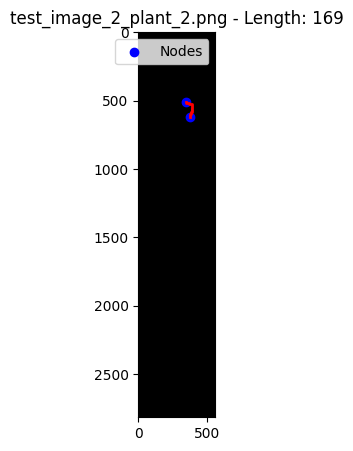

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png
Highest node: (523, 294), Lowest node: (1340, 164)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_3.png


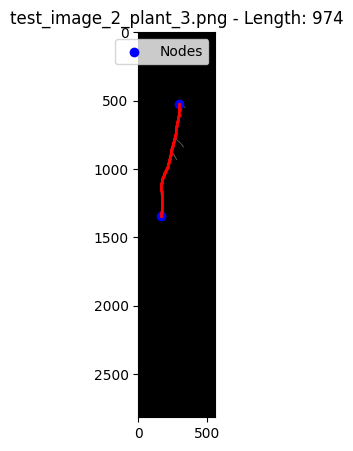

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png
Highest node: (551, 272), Lowest node: (1887, 203)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_4.png


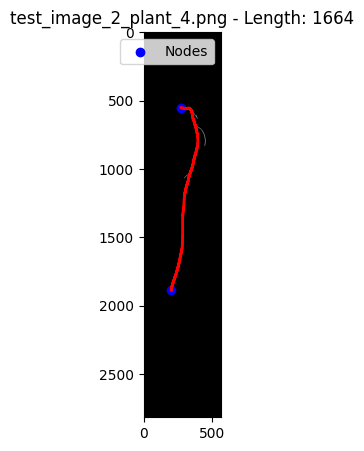

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png
Highest node: (549, 171), Lowest node: (1659, 0)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_2_plant_5.png


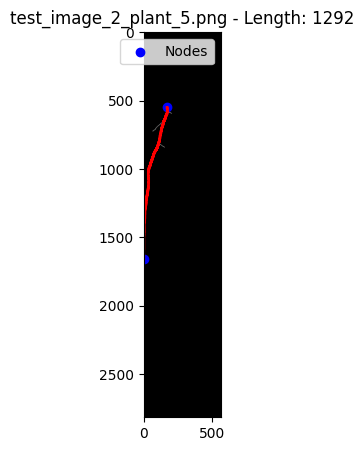

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png
Highest node: (516, 437), Lowest node: (670, 424)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_1.png


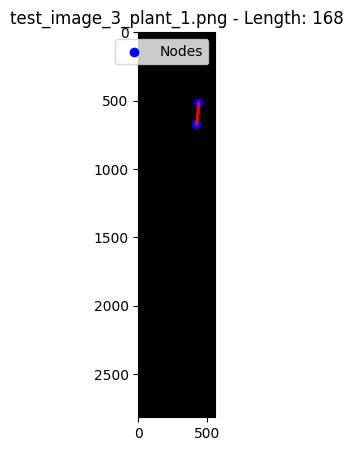

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_2.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_2.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_4.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_3_plant_4.png. Marking as seed

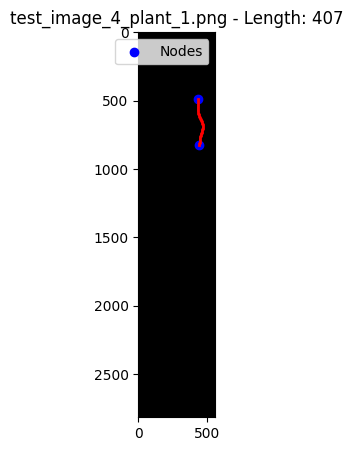

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png
Highest node: (511, 381), Lowest node: (807, 413)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_2.png


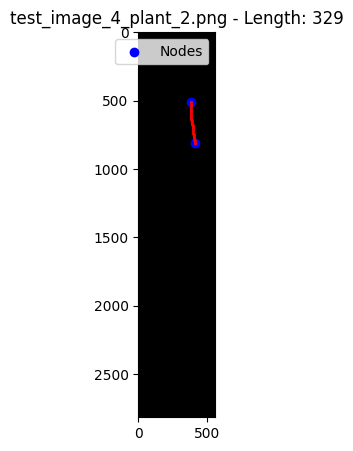

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_4.png
Highest node: (531, 271), Lowest node:

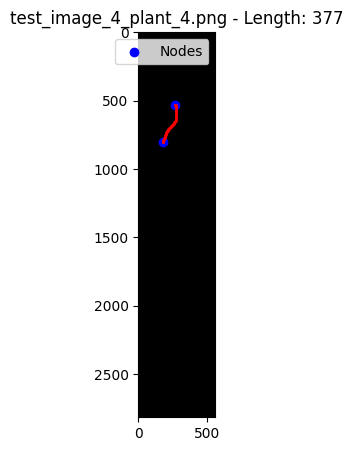

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png
Highest node: (527, 211), Lowest node: (635, 209)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_4_plant_5.png


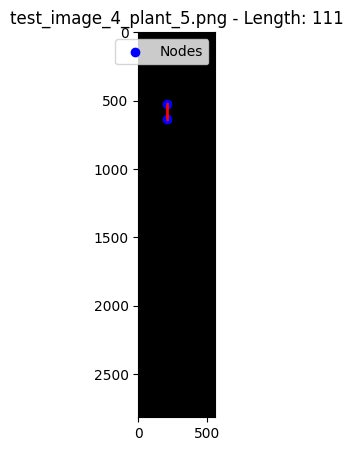

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png
Highest node: (579, 405), Lowest node: (816, 441)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_1.png


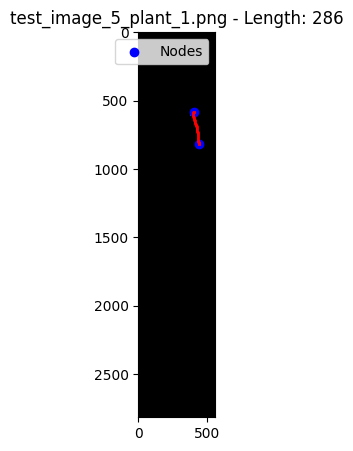

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png
Highest node: (548, 361), Lowest node: (760, 345)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_2.png


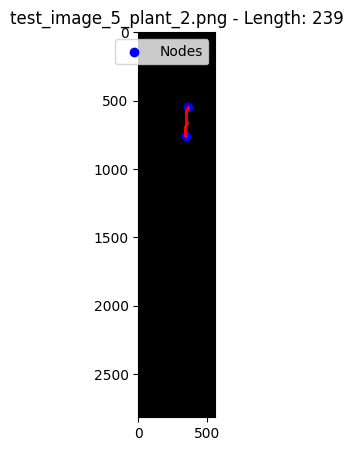

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_4.png
Highest node: (541, 241), Lowest node:

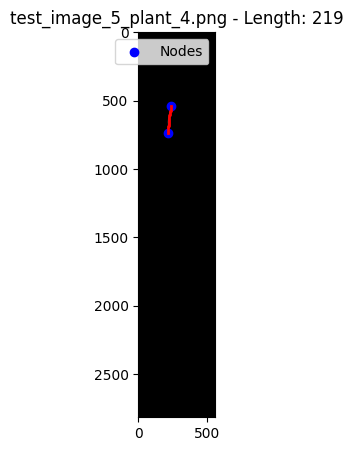

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png
Highest node: (524, 195), Lowest node: (719, 244)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_5_plant_5.png


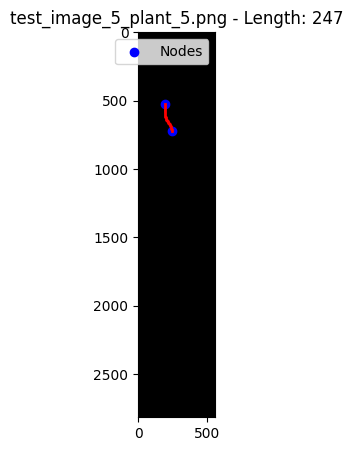

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png
Highest node: (531, 415), Lowest node: (825, 436)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_1.png


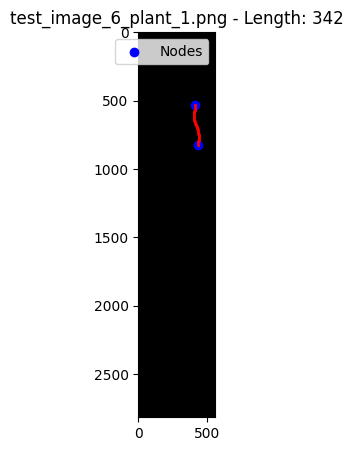

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png
Highest node: (512, 336), Lowest node: (979, 278)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_2.png


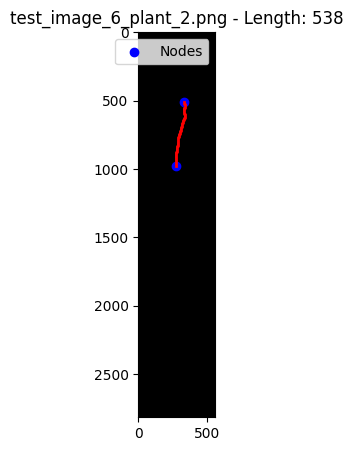

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png
Highest node: (549, 302), Lowest node: (976, 230)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_3.png


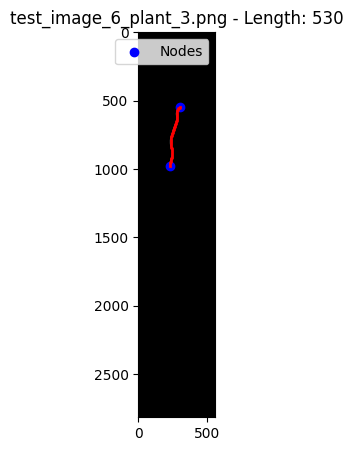

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png
Highest node: (543, 228), Lowest node: (951, 195)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_4.png


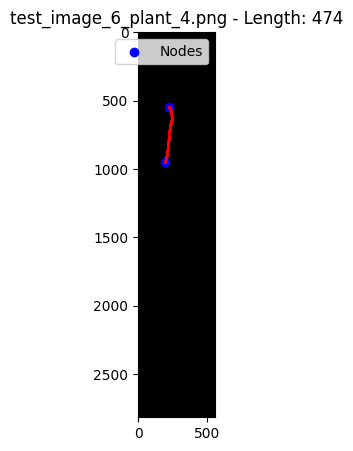

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png
Highest node: (522, 165), Lowest node: (775, 154)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_6_plant_5.png


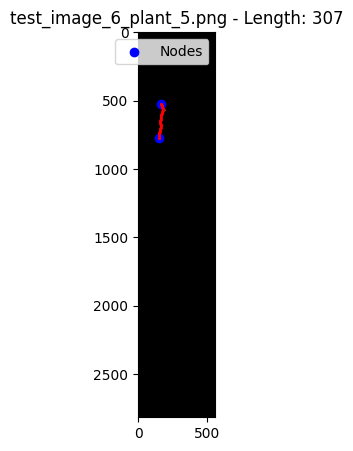

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png
Highest node: (537, 395), Lowest node: (925, 425)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_1.png


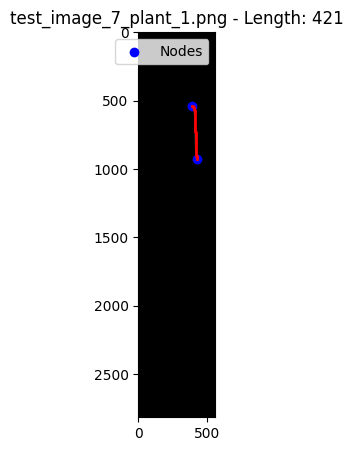

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png
Highest node: (518, 331), Lowest node: (698, 345)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_2.png


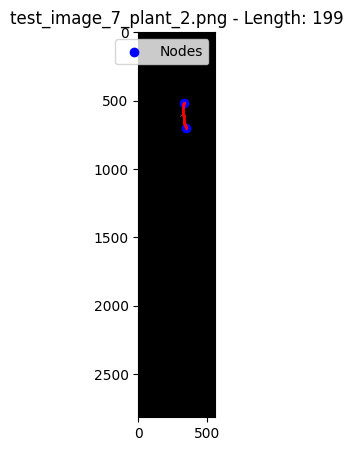

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_3.png
No significant root found for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_3.png. Marking as seed.
Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_4.png
Highest node: (528, 231), Lowest node:

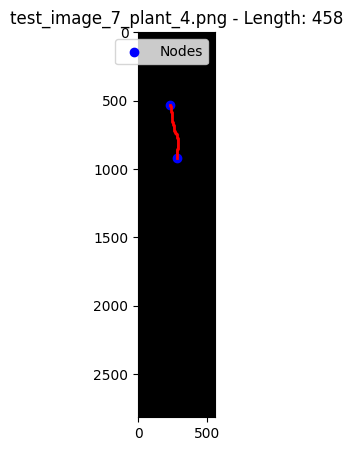

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png
Highest node: (547, 195), Lowest node: (993, 207)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_7_plant_5.png


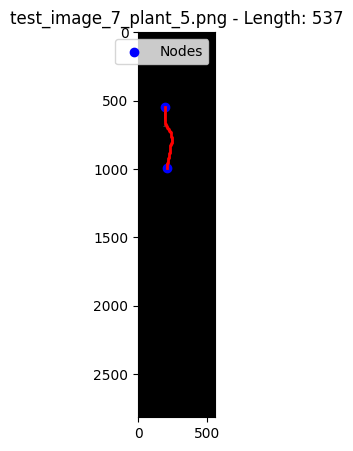

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png
Highest node: (496, 434), Lowest node: (2464, 215)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_1.png


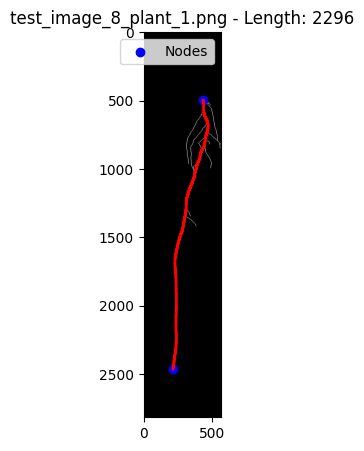

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png
Highest node: (546, 382), Lowest node: (2531, 41)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_2.png


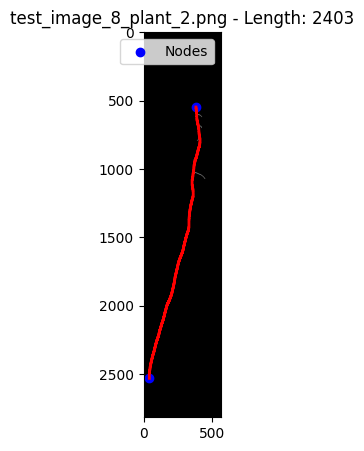

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png
Highest node: (511, 324), Lowest node: (1918, 349)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_3.png


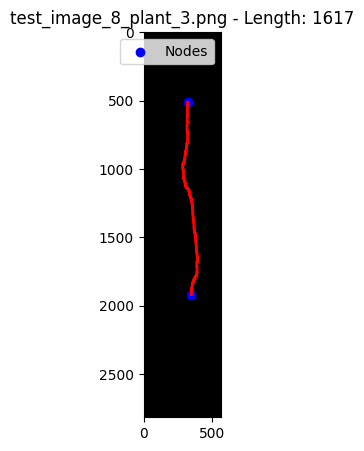

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png
Highest node: (518, 275), Lowest node: (1604, 0)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_4.png


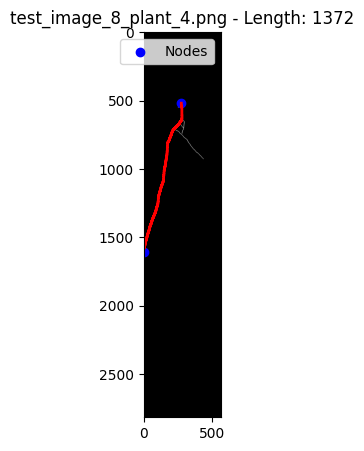

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png
Highest node: (514, 213), Lowest node: (1167, 195)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_8_plant_5.png


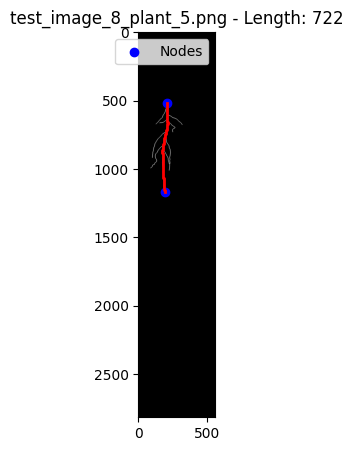

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png
Highest node: (530, 416), Lowest node: (1072, 444)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_1.png


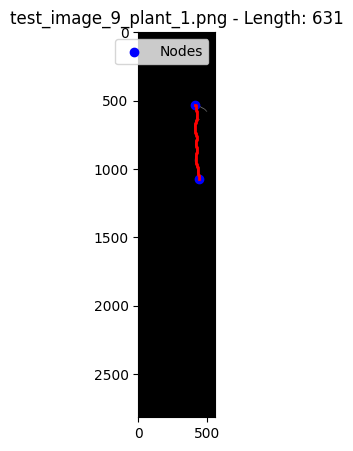

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png
Highest node: (511, 357), Lowest node: (1020, 333)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_2.png


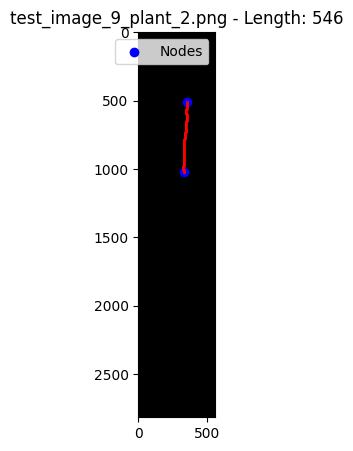

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png
Highest node: (523, 334), Lowest node: (1145, 290)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_3.png


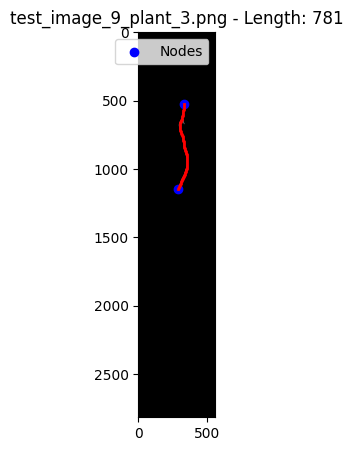

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png
Highest node: (516, 284), Lowest node: (936, 297)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_4.png


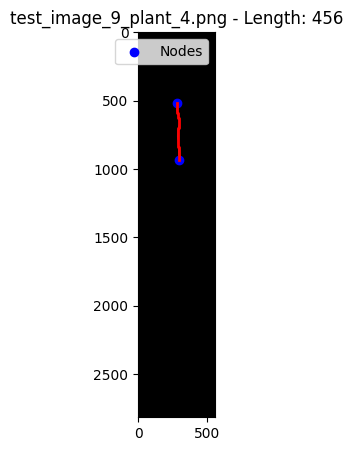

Processing: C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Original mask loaded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Seeds excluded for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Primary root isolated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Skeletonization completed for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Graph created for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png
Highest node: (511, 223), Lowest node: (1122, 217)
Shortest path calculated for C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\test_image_9_plant_5.png


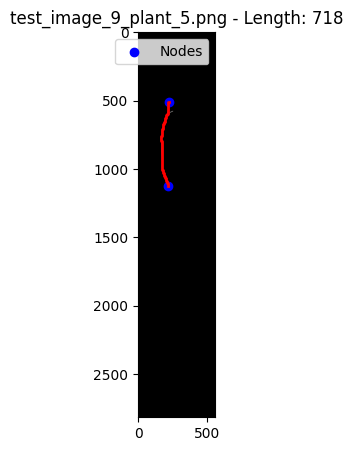

test_image_10_plant_1.png: Root length = 1270 pixels
test_image_10_plant_2.png: Root length = 1871 pixels
test_image_10_plant_3.png: Root length = 1319 pixels
test_image_10_plant_4.png: Root length = 1391 pixels
test_image_10_plant_5.png: Root length = 1192 pixels
test_image_11_plant_1.png: Root length = 1240 pixels
test_image_11_plant_2.png: Root length = 1539 pixels
test_image_11_plant_3.png: Root length = 1598 pixels
test_image_11_plant_4.png: Root length = 1671 pixels
test_image_11_plant_5.png: Root length = 1315 pixels
test_image_12_plant_1.png: Root length = 1084 pixels
test_image_12_plant_2.png: Root length = 1357 pixels
test_image_12_plant_3.png: Root length = 994 pixels
test_image_12_plant_4.png: Root length = 1097 pixels
test_image_12_plant_5.png: Root length = 1073 pixels
test_image_13_plant_1.png: Root length = 1575 pixels
test_image_13_plant_2.png: Root length = 1234 pixels
test_image_13_plant_3.png: Root length = 1225 pixels
test_image_13_plant_4.png: Root length = 1426 p

In [9]:
import os
import cv2
import numpy as np
import networkx as nx
from skimage.morphology import skeletonize, dilation, disk
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

# Path to the folder with masks
folder_path = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks"

# Function to preprocess the mask and exclude seeds
def preprocess_and_exclude_seeds(mask, size_threshold=500):
    # Convert to binary
    _, binary_mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Label connected components
    labeled_mask = label(binary_mask)

    # Remove small components (likely seeds)
    filtered_mask = np.zeros_like(binary_mask)
    regions = regionprops(labeled_mask)
    for region in regions:
        if region.area > size_threshold:  # Adjust size threshold as needed
            filtered_mask[labeled_mask == region.label] = 1

    return filtered_mask

# Function to isolate the primary root
def isolate_primary_root(binary_mask):
    # Label connected components
    labeled_mask = label(binary_mask)
    regions = regionprops(labeled_mask)

    # Identify the component with the largest vertical span
    max_vertical_span = 0
    primary_label = 0
    for region in regions:
        min_row, _, max_row, _ = region.bbox
        vertical_span = max_row - min_row
        if vertical_span > max_vertical_span:
            max_vertical_span = vertical_span
            primary_label = region.label

    # Create a mask for the primary root
    primary_root = labeled_mask == primary_label
    return primary_root

# Function to calculate the shortest path between closest connected nodes
def calculate_closest_path(graph, highest_node, lowest_node):
    # If no path exists, find the closest nodes
    if not nx.has_path(graph, highest_node, lowest_node):
        print(f"No direct path between {highest_node} and {lowest_node}. Finding closest nodes...")
        # Find distances from highest_node to all other nodes
        distances = {node: np.linalg.norm(np.array(node) - np.array(lowest_node)) for node in graph.nodes}
        # Find the closest node to the lowest_node
        closest_node = min(distances, key=distances.get)
        return nx.shortest_path(graph, source=highest_node, target=closest_node)
    else:
        # Direct path exists
        return nx.shortest_path(graph, source=highest_node, target=lowest_node)

# Function to calculate the root length
def calculate_root_length(image_path):
    print(f"Processing: {image_path}")
    # Load the mask
    mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to load image: {image_path}")
    print(f"Original mask loaded for {image_path}")

    # Preprocess the mask to exclude seeds
    filtered_mask = preprocess_and_exclude_seeds(mask)
    if np.sum(filtered_mask) == 0:
        print(f"No significant root found for {image_path}. Marking as seed.")
        return 0, None, None, None, None  # Return length 0 for seeds

    print(f"Seeds excluded for {image_path}")

    # Isolate the primary root
    primary_root_mask = isolate_primary_root(filtered_mask)
    if np.sum(primary_root_mask) == 0:
        print(f"Primary root not found for {image_path}. Marking as seed.")
        return 0, None, None, None, None  # Return length 0 for seeds

    print(f"Primary root isolated for {image_path}")

    # Skeletonize the primary root
    skeleton = skeletonize(primary_root_mask)
    if not np.any(skeleton):
        print(f"Skeleton is empty for {image_path}. Marking as seed.")
        return 0, None, None, None, None  # Return length 0 for seeds

    print(f"Skeletonization completed for {image_path}")

    # Dilate the skeleton slightly to ensure connectivity
    skeleton = dilation(skeleton, disk(1))

    # Find the coordinates of the non-zero points (nodes)
    coords = np.argwhere(skeleton)

    # Create a graph from the skeleton
    graph = nx.Graph()
    for y, x in coords:
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Connect 4-neighbors
            ny, nx_ = y + dy, x + dx
            if (ny, nx_) in map(tuple, coords):
                graph.add_edge((y, x), (ny, nx_))
    print(f"Graph created for {image_path}")

    # Find the highest and lowest nodes
    highest_node = tuple(coords[np.argmin(coords[:, 0])])
    lowest_node = tuple(coords[np.argmax(coords[:, 0])])
    print(f"Highest node: {highest_node}, Lowest node: {lowest_node}")

    # Calculate the shortest path between the highest and lowest nodes (or closest connected nodes)
    path = calculate_closest_path(graph, highest_node, lowest_node)
    print(f"Shortest path calculated for {image_path}")

    # Compute the path length
    path_length = len(path)

    return path_length, skeleton, path, highest_node, lowest_node

# Process each mask in the folder
results = {}
for file_name in os.listdir(folder_path):
    if file_name.endswith(".png"):
        image_path = os.path.join(folder_path, file_name)
        try:
            length, skeleton, path, high, low = calculate_root_length(image_path)
            results[file_name] = length

            # Visualization for non-seeds
            if length > 0:
                plt.figure(figsize=(5, 5))
                plt.imshow(skeleton, cmap="gray")
                y, x = zip(*path)
                plt.plot(x, y, color="red", linewidth=2)
                plt.scatter([high[1], low[1]], [high[0], low[0]], color="blue", label="Nodes")
                plt.title(f"{file_name} - Length: {length}")
                plt.legend()
                plt.show()
        except Exception as e:
            print(f"Error processing {file_name}: {e}")

# Print results
for file, length in results.items():
    print(f"{file}: Root length = {length} pixels")



In [10]:
# After processing and populating the `results` dictionary, save it to a CSV file
# Convert the `results` dictionary into a pandas DataFrame
data = [{"Plant ID": file, "Length (px)": length} for file, length in results.items()]
df = pd.DataFrame(data)

# Specify the path for the CSV file
csv_path = r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\primary_root_lengths_v2.csv"

# Save the DataFrame to a CSV file
df.to_csv(csv_path, index=False)

print(f"Results saved to {csv_path}")


Results saved to C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\primary_root_lengths_v2.csv


In [11]:

df = pd.read_csv(r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\primary_root_lengths_v2.csv")
df

,Plant ID,Length (px)
0,test_image_10_plant_1.png,1270
1,test_image_10_plant_2.png,1871
2,test_image_10_plant_3.png,1319
3,test_image_10_plant_4.png,1391
4,test_image_10_plant_5.png,1192
...,...,...
85,test_image_9_plant_1.png,631
86,test_image_9_plant_2.png,546
87,test_image_9_plant_3.png,781
88,test_image_9_plant_4.png,456


In [12]:
data =  r"C:\Users\salop\Documents\Data\Kaggle\Kaggle\divided_masks\primary_root_lengths_v2.csv"
data = pd.read_csv(data)

# Rearrange rows: moving rows 47 to 91 to the top and the rest below
reordered_data = pd.concat([data.iloc[45:92], data.iloc[:45], data.iloc[92:]])

# Remove .png from the 'Plant ID' column
reordered_data['Plant ID'] = reordered_data['Plant ID'].str.replace('.png', '')
# Save the reordered data back to a new CSV file
output_path = r"C:\Users\salop\Documents\GitHub\FAI2\2024-25b-fai2-adsai-MariaSalop230574\datalab_tasks\task8\primary_root_lengths_v2.csv"
reordered_data.to_csv(output_path, index=False)

print("Reordering complete. The reordered file has been saved to:", output_path)

Reordering complete. The reordered file has been saved to: C:\Users\salop\Documents\GitHub\FAI2\2024-25b-fai2-adsai-MariaSalop230574\datalab_tasks\task8\primary_root_lengths_v2.csv


In [13]:
df = pd.read_csv(r"C:\Users\salop\Documents\GitHub\FAI2\2024-25b-fai2-adsai-MariaSalop230574\datalab_tasks\task8\primary_root_lengths_v2.csv")
df

,Plant ID,Length (px)
0,test_image_1_plant_1,632
1,test_image_1_plant_2,0
2,test_image_1_plant_3,272
3,test_image_1_plant_4,0
4,test_image_1_plant_5,0
...,...,...
85,test_image_18_plant_1,696
86,test_image_18_plant_2,1295
87,test_image_18_plant_3,0
88,test_image_18_plant_4,1408
